# Python Code Development for HCMST Analysis

In [1]:
import diversedata as dd
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import altair as alt
from IPython.display import Markdown

## Data Cleaning and Processing

In [2]:
hcmst = dd.load_data("hcmst")

# Review total rows
hcmst.shape[0]

# Select features of interest and removing NA
hcmst = hcmst[
    [
        "same_sex_couple",
        "sex_frequency",
        "flirts_with_partner",
        "fights_with_partner",
        "inc_change_during_pandemic",
        "subject_had_covid",
        "partner_had_covid",
        "subject_vaccinated",
        "partner_vaccinated",
        "agree_covid_approach",
        "relationship_quality",
    ]
].dropna()

# Remaining row count.
hcmst.shape[0]

1220

## 2. Variable Encoding

In [3]:
# check R level prints

In [4]:
hcmst['same_sex_couple'] = pd.Categorical(
    hcmst['same_sex_couple'],
    categories=['no', 'yes'],
)
print(f'same_sex_couple levels: {hcmst["same_sex_couple"].cat.categories.tolist()}')

same_sex_couple levels: ['no', 'yes']


In [5]:
behavioral_variables_levels = {
    "sex_frequency" : [
        "once_a_month_or_less", "2_to_3_times_a_month",
        "once_or_twice_a_week", "3_to_6_times_a_week",
        "once_or_more_a_day"
    ],
    "flirts_with_partner" : [
        "never", "less_than_once_a_month", 
        "1_to_3_times_a_month", "once_a_week", 
        "a_few_times_a_week", "every_day"
    ],
    "fights_with_partner" : [
        "0_times", "1_time", "2_times", "3_times", "4_times", 
        "5_times", "6_times", "7_or_more_times"
    ],
}

for variable, levels in behavioral_variables_levels.items():
    hcmst[variable] = pd.Categorical(
        hcmst[variable],
        categories=levels,
        ordered=True
    )
    print(f'{variable} levels: {", ".join(hcmst[variable].cat.categories)} \n')

sex_frequency levels: once_a_month_or_less, 2_to_3_times_a_month, once_or_twice_a_week, 3_to_6_times_a_week, once_or_more_a_day 

flirts_with_partner levels: never, less_than_once_a_month, 1_to_3_times_a_month, once_a_week, a_few_times_a_week, every_day 

fights_with_partner levels: 0_times, 1_time, 2_times, 3_times, 4_times, 5_times, 6_times, 7_or_more_times 



In [6]:
covid_19_variables_levels = {
    "inc_change_during_pandemic": [
        "much_worse", "worse", "no_change", "better", "much_better"
    ],
    "subject_had_covid": [
        "no", "yes"
    ],
    "partner_had_covid": [
        "no", "yes"
    ],
    "subject_vaccinated": [
        "not_vaccinated", "partially_vaccinated", 
        "fully_vaccinated_no_booster", "fully_vaccinated_and_booster"
    ],
    "partner_vaccinated": [
        "not_vaccinated", "partially_vaccinated", 
        "fully_vaccinated_no_booster", "fully_vaccinated_and_booster"
    ],
    "agree_covid_approach": [
        "completely_disagree", "mostly_disagree", 
        "mostly_agree", "completely_agree"
    ],
}

for variable, levels in covid_19_variables_levels.items():
    hcmst[variable] = pd.Categorical(
        hcmst[variable],
        categories=levels,
        ordered=True
    )
    print(f'{variable} levels: {", ".join(hcmst[variable].cat.categories)} \n')

inc_change_during_pandemic levels: much_worse, worse, no_change, better, much_better 

subject_had_covid levels: no, yes 

partner_had_covid levels: no, yes 

subject_vaccinated levels: not_vaccinated, partially_vaccinated, fully_vaccinated_no_booster, fully_vaccinated_and_booster 

partner_vaccinated levels: not_vaccinated, partially_vaccinated, fully_vaccinated_no_booster, fully_vaccinated_and_booster 

agree_covid_approach levels: completely_disagree, mostly_disagree, mostly_agree, completely_agree 



In [7]:
hcmst["relationship_quality"] = pd.Categorical(
    hcmst["relationship_quality"],
    categories=[
        "very_poor", "poor", "fair", "good", "excellent"
    ],
    ordered=True,
)
print(f'relationship_quality levels: {hcmst["relationship_quality"].cat.categories.tolist()}')

## change R print to relationship_quality instead of sex freq

relationship_quality levels: ['very_poor', 'poor', 'fair', 'good', 'excellent']


## 3. Exploratory Data Analysis

In [8]:
alt.Chart(hcmst).mark_bar().encode(
    x=alt.X("same_sex_couple").title("Same Sex Couple"),
    y=alt.Y("count()").title("Count"),
    color=alt.Color("same_sex_couple", legend=None),
).properties(title="Couple Type Distribution", width=350, height=350)

alt.Chart(...)

In [9]:
def histogram_plot(data, y_var, facet, label_map, plot_title="Relative Frequency by Category"):
    data_cleaned = data.groupby(by=[y_var, facet], observed=False).size().reset_index(name='count')
    data_cleaned['prop'] = data_cleaned.groupby(facet, observed=False)['count'].transform(lambda x: x / x.sum())
    data_cleaned[y_var] = data_cleaned[y_var].cat.rename_categories(label_map)

    plot = alt.Chart(data_cleaned).mark_bar(size=10).encode(
        x=alt.X('prop').title('Relative Frequency'),
        y=alt.Y(y_var).title(None).scale(alt.Scale(reverse=True)),
        yOffset='same_sex_couple',
        color=alt.Color('same_sex_couple').title("Same Sex Couple"),
    ).properties(title=plot_title, width=400, height=alt.Step(10))
    
    return plot

In [10]:
sex_freq_labels = {
  "once_a_month_or_less": "Once a Month or Less",
  "2_to_3_times_a_month": "Two or Three Times a Month",
  "once_or_twice_a_week": "Once or Twice a Week",
  "3_to_6_times_a_week": "Three to Six Times a Week",
  "once_or_more_a_day": "Once or More a Day"
}
hist_sex_freq = histogram_plot(hcmst, 'sex_frequency', 'same_sex_couple', sex_freq_labels, 'Sex Frequency')

flirt_freq_labels = {
  "never": "Never",
  "less_than_once_a_month": "Less Than Once a Month",
  "1_to_3_times_a_month": "One to Three Times a Month",
  "once_a_week": "Once a Week",
  "a_few_times_a_week": "A Few Times a Week",
  "every_day": "Every Day" 
}
hist_flirt_freq = histogram_plot(hcmst, "flirts_with_partner", "same_sex_couple", flirt_freq_labels, "Flirting Frequency")

fight_freq_labels = {
  "0_times": "Zero Times",
  "1_time": "One Time",
  "2_times": "Two Times",
  "3_times": "Three Times",
  "4_times": "Four Times",
  "5_times": "Five Times",
  "6_times": "Six Times",
  "7_or_more_times": "Seven or More Times"
}
hist_fight_freq = histogram_plot(hcmst, "fights_with_partner", "same_sex_couple", fight_freq_labels, "Fighting Frequency")

inc_labels = {
  "much_worse": "Much Worse",
  "worse": "Worse",
  "no_change": "No Change",
  "better": "Better",
  "much_better": "Much Better"
}
hist_inc_change_freq = histogram_plot(hcmst, "inc_change_during_pandemic", "same_sex_couple", inc_labels, "Income Change During Pandemic Frequency")

yes_no_label = {
    "no": "No", "yes": "Yes"
}
hist_sub_covid_freq = histogram_plot(hcmst, "subject_had_covid", "same_sex_couple", yes_no_label, "Subject had COVID-19 Frequency")
hist_par_covid_freq = histogram_plot(hcmst, "partner_had_covid", "same_sex_couple", yes_no_label, "Partner had COVID-19 Frequency")

vax_label ={
  "not_vaccinated": "Not Vaccinated",
  "partially_vaccinated": "Partially Vaccinated",
  "fully_vaccinated_no_booster": "Fully Vaccinated No Booster",
  "fully_vaccinated_and_booster": "Fully Vaccinated and Booster"
}
hist_sub_vax_freq = histogram_plot(hcmst, "subject_vaccinated", "same_sex_couple", vax_label, "Subject Vaccination Status Frequency")
hist_par_vax_freq = histogram_plot(hcmst, "partner_vaccinated", "same_sex_couple", vax_label, "Partner Vaccination Status Frequency")

approach_label = {
  "completely_disagree": "Completely Disagree",
  "mostly_disagree": "Mostly Disagree",
  "mostly_agree": "Mostly Agree",
  "completely_agree": "Completely Agree"
}
hist_cov_approach_freq = histogram_plot(hcmst, "agree_covid_approach", "same_sex_couple", approach_label, "Agreement on Pandemic Approach Frequency")

quality_label = {
  "very_poor": "Very Poor",
  "poor": "Poor",
  "fair": "Fair",
  "good": "Good",
  "excellent": "Excellent"
}
hist_quality_freq = histogram_plot(hcmst, "relationship_quality", "same_sex_couple", quality_label, "Relationship Quality Frequency")

alt.vconcat(
  hist_sex_freq,
  hist_flirt_freq,
  hist_fight_freq,
  hist_inc_change_freq,
  hist_sub_covid_freq,
  hist_par_covid_freq,
  hist_sub_vax_freq,
  hist_par_vax_freq,
  hist_cov_approach_freq,
  hist_quality_freq
).resolve_legend(color='independent')

alt.VConcatChart(...)

## 4. Model Fitting and Assumptions

In this Python analysis, we will be fitting a **Multi-Class Logistic Regression Model**, finding its feature importances, and assessing how well it predicts on unseen data.

In [11]:
# add scikit-learn to conda env

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report
)
from sklearn.dummy import DummyClassifier

First, let's separate our predictors from the target.

Then, split our data into train and test sets, with the random state specified to make our work reproducible. We'll also stratify to ensure that the train and test sets have the same class distribution

In [14]:
X = hcmst.drop(columns=['relationship_quality'])
y = hcmst['relationship_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

Since all of the predictors are ordinal, we'll use `OrdinalEncoder` to encode them. Since there are no missing values, imputation is not needed. This preprocessing is necessary since most `scikit-learn` algorithms require numerical inputs.

Note: `OrdinalEncoder` will encode the levels of an ordinal column to be equally spaced apart. This may not be desireable for some analyses.

Don't forget to only `fit_transform` on the training set and only `transform` on the testing set! We don't want to break the golden rule.

In [15]:
# make sure the specified order for the variables are maintained
level_order = [
    hcmst["same_sex_couple"].cat.categories.tolist(),
    hcmst["sex_frequency"].cat.categories.tolist(),
    hcmst["flirts_with_partner"].cat.categories.tolist(),
    hcmst["fights_with_partner"].cat.categories.tolist(),
    hcmst["inc_change_during_pandemic"].cat.categories.tolist(),
    hcmst["subject_had_covid"].cat.categories.tolist(),
    hcmst["partner_had_covid"].cat.categories.tolist(),
    hcmst["subject_vaccinated"].cat.categories.tolist(),
    hcmst["partner_vaccinated"].cat.categories.tolist(),
    hcmst["agree_covid_approach"].cat.categories.tolist(),
]

preprocessor = OrdinalEncoder(categories=level_order)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

Now that our data has been preprocessed, let's fit our model! Let's also fit a dummy model to compare their performance.

Since `scikit-learn` doesn't support ordinal regression at the time of writing, we will use a multinomial logistic regression model via `LogisticRegression()` which will automatically be multinomial if there is more than 2 target classes. We will again set the random state for reproducibility.

In [16]:
logistic_regression_model = LogisticRegression(random_state=123, max_iter=250, n_jobs=-1)
logistic_regression_model.fit(X_train_transformed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'lbfgs'
,max_iter,250
,multi_class,'deprecated'


## 5. Model Interpretation

Now, we can take a look at the feature importances via the absolute value of the coefficients of the logistic regression model that we fitted.

In [17]:
# get absolute value coefficients into a dataframe
feature_names = X.columns
classes = logistic_regression_model.classes_

abs_coef_df = pd.DataFrame(
    np.abs(logistic_regression_model.coef_.T),
    columns=classes,
    index=feature_names
)

abs_coef_long = abs_coef_df.reset_index().melt(
    id_vars='index',
    var_name='class',
    value_name='absolute_value_coefficient'
).rename(columns={'index': 'feature'})

# clean up labels for visualization
abs_coef_long['class'] = abs_coef_long['class'].str.replace('_', ' ').str.title()
abs_coef_long['feature'] = abs_coef_long['feature'].str.replace('_', ' ').str.title()

# make visualization
alt.Chart(abs_coef_long).mark_bar().encode(
    x=alt.X('absolute_value_coefficient').title('| Coefficient |'),
    y=alt.Y('feature').sort('x').title('Feature'),
).properties(
    width=150, height=150
).facet(
    facet=alt.Facet('class').title('Relationship Quality').sort('descending'),
    columns=2
).resolve_scale(
    y='independent'
)

alt.FacetChart(...)

Above, we can see that the feature "Partner Had Covid" is the most influential predictor for the "Very Poor" and "Poor" relationship quality classes.  
For the "Good" class, "Same Sex Couple" is the most important feature.  
Meanwhile, "Fights With Partner" is the strongest predictor for the "Fair" class, and "Agree Covid Approach" is the strongest predictor for the "Excellent" class.

Note: These feature importances reflect how the model uses the features to make predictions, but they do **not** imply causal relationships or real-world effects.

## 6. Prediction

Let's see how well our model predicts using unseen data.

In [18]:
# accuracy
# use confusion matrix
predictions = logistic_regression_model.predict(X_test_transformed)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=classes))

              precision    recall  f1-score   support

   excellent       0.63      0.77      0.70       189
        fair       0.71      0.17      0.28        29
        good       0.50      0.46      0.48       140
        poor       0.00      0.00      0.00         7
   very_poor       0.00      0.00      0.00         1

    accuracy                           0.59       366
   macro avg       0.37      0.28      0.29       366
weighted avg       0.57      0.59      0.56       366



C:\Users\Stephanie\miniforge3\envs\diverse_web_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Stephanie\miniforge3\envs\diverse_web_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Stephanie\miniforge3\envs\diverse_web_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

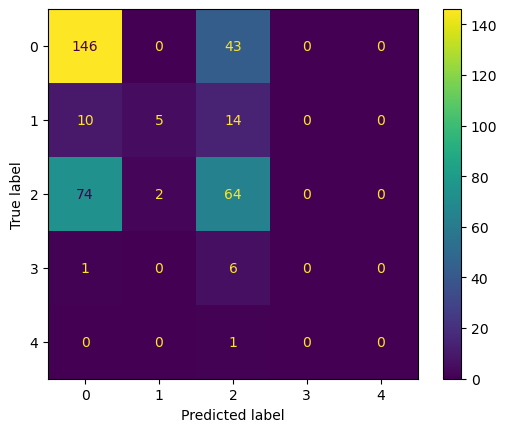

In [32]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [21]:
y_test.value_counts()

relationship_quality
excellent    189
good         140
fair          29
poor           7
very_poor      1
Name: count, dtype: int64

In [24]:
pd.Series(predictions).value_counts()

excellent    231
good         128
fair           7
Name: count, dtype: int64

In [27]:
# note no poor or very poor predictions

To further evaluate our model, let's compare it to a baseline model that only predicts the most common class in the training data.

In [19]:
baseline_model = DummyClassifier()
baseline_model.fit(X_train_transformed, y_train)
baseline_predictions = baseline_model.predict(X_test_transformed)